In [19]:
import json

DATA_NAME = "SEED"
BASE_PATH = r"C:/Users/Archery/Desktop/学习/大二下/机器学习及医学工程中应用/共选题/course_project"

DATA_INFO_PATH = f"{BASE_PATH}/{DATA_NAME}/dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

=== Dataset Intro ===
Categories: ['negative', 'neutral', 'positive']
Channels (count): 62
Channels: ['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 2.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [20]:
import h5py
import numpy as np
DATA_NAME = "SEED"
INDEX_PATH_TRAIN = f"{BASE_PATH}/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"{BASE_PATH}/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"{BASE_PATH}/{DATA_NAME}/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("\n=== Train ===")
    print("keys:", list(f.keys()))
    print("X dtype:", f["X"].dtype)
    print("X shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    print("labels:", np.unique(f["y"][()]))

with h5py.File(INDEX_PATH_VAL, "r") as f:
    print("\n=== Val ===")
    print("keys:", list(f.keys()))
    print("X shape:", f["X"].shape)
    print("y shape:", f["y"].shape)
    print("labels:", np.unique(f["y"][()]))

with h5py.File(INDEX_PATH_TEST, "r") as f:
    print("\n=== Test ===")
    print("keys:", list(f.keys()))
    print("X shape:", f["X"].shape)


=== Train ===
keys: ['X', 'y']
X dtype: float32
X shape: (900, 62, 400)
y dtype: int64
y shape: (900,)
labels: [0 1 2]

=== Val ===
keys: ['X', 'y']
X shape: (450, 62, 400)
y shape: (450,)
labels: [0 1 2]

=== Test ===
keys: ['X']
X shape: (450, 62, 400)


## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [21]:
import torch
import torch.nn as nn

class EEGNormalize(nn.Module):
    def forward(self, x):
        mean = x.mean(dim=2, keepdim=True)
        std = x.std(dim=2, keepdim=True)
        x = (x - mean) / (std + 1e-6)
        return x


class EEGNetClassifier(nn.Module):  # EEGNet-8,2
    def __init__(self, chans, time_point=400, num_classes=3, f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1, norm=torch.nn.Identity()):
        super(EEGNetClassifier, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm = norm
        self.classifier = nn.Linear(self.embed_dim, num_classes)

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        x = self.norm(x)

        x = x.unsqueeze(dim=1)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.flatten(start_dim=1)
        logits = self.classifier(x)

        return logits

In [22]:
class MultiScaleEEGNetClassifier(nn.Module):
    def __init__(
        self,
        chans,
        time_point=400,
        num_classes=3,
        f1=4,
        d=2,
        pk1=4,
        pk2=8,
        dp=0.5,
        max_norm1=1,
        norm=torch.nn.Identity()
    ):
        super(MultiScaleEEGNetClassifier, self).__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(f1),
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 32), padding=(0, 16), bias=False),
            nn.BatchNorm2d(f1),
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(f1),
        )

        in_ch = f1 * 3
        f2 = in_ch * d

        self.block2 = nn.Sequential(
            nn.Conv2d(in_ch, f2, (chans, 1), groups=in_ch, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(f2, f2, (1, 16), groups=f2, bias=False, padding=(0, 8)),
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)

        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm = norm
        self.classifier = nn.Linear(self.embed_dim, num_classes)

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        x = self.norm(x)

        x = x.unsqueeze(dim=1)

        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)

        x = torch.cat([x1, x2, x3], dim=1)

        x = self.block2(x)
        x = self.block3(x)

        x = x.flatten(start_dim=1)
        logits = self.classifier(x)

        return logits

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


CHANNELS = 62
patch_size = 400
CLASSES = 3
labels = [0 1 2]
Epoch [01/50] | Train Loss: 1.1250 | Train Acc: 0.3233 | Val Loss: 1.0987 | Val Acc: 0.3356
Epoch [02/50] | Train Loss: 1.0972 | Train Acc: 0.3678 | Val Loss: 1.0970 | Val Acc: 0.3444
Epoch [03/50] | Train Loss: 1.0853 | Train Acc: 0.3989 | Val Loss: 1.0955 | Val Acc: 0.3733
Epoch [04/50] | Train Loss: 1.0842 | Train Acc: 0.3956 | Val Loss: 1.0990 | Val Acc: 0.3489
Epoch [05/50] | Train Loss: 1.0738 | Train Acc: 0.4111 | Val Loss: 1.0996 | Val Acc: 0.3689
Epoch [06/50] | Train Loss: 1.0661 | Train Acc: 0.4178 | Val Loss: 1.0974 | Val Acc: 0.3622
Epoch [07/50] | Train Loss: 1.0558 | Train Acc: 0.4511 | Val Loss: 1.1009 | Val Acc: 0.3711
Epoch [08/50] | Train Loss: 1.0321 | Train Acc: 0.4767 | Val Loss: 1.1011 | Val Acc: 0.3911
Epoch [09/50] | Train Loss: 1.0455 | Train Acc: 0.4511 | Val Loss: 1.0975 | Val Acc: 0.3822
Epoch [10/50] | Train Loss: 1.0276 | Train Acc: 0.4667 | Val Loss: 1.0964 | Val Acc: 0.3956
Epoch [11/50] | Trai

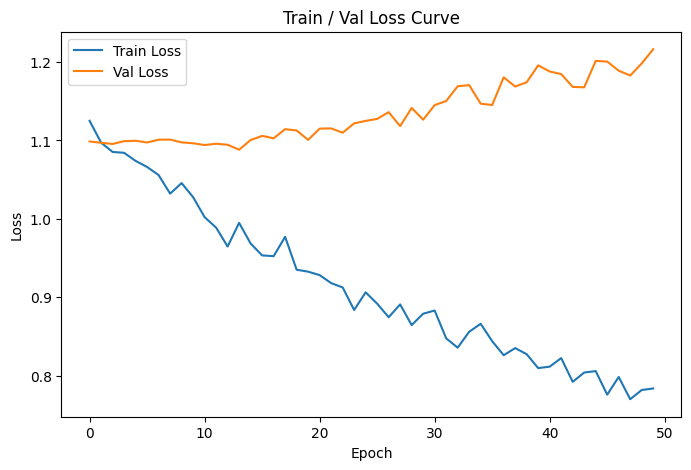

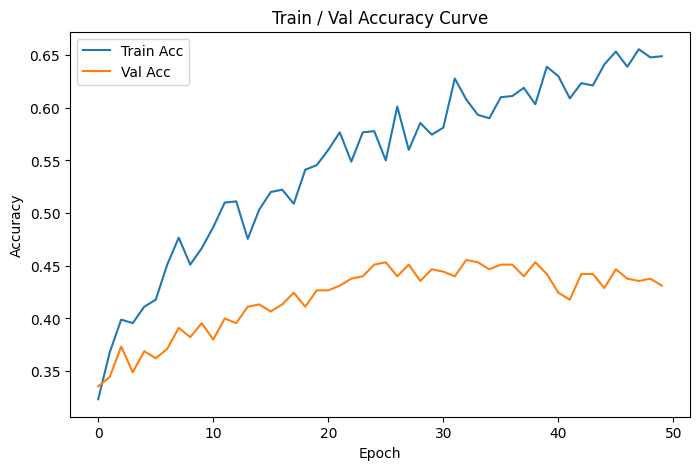

----------------------------------------
Test input shape: torch.Size([1, 62, 400])
Test output shape: torch.Size([1, 3])


In [23]:
import h5py
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from course_project.TEST_DATASET import TrainDataset, TestDataset

# 改自动读取SEED形状
with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    x_shape = f["X"].shape
    y_train = f["y"][()]

CHANNELS = x_shape[1]      # 62
patch_size = x_shape[2]    # 400
CLASSES = len(np.unique(y_train))  # 3

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3

print("CHANNELS =", CHANNELS)
print("patch_size =", patch_size)
print("CLASSES =", CLASSES)
print("labels =", np.unique(y_train))


# -------------------------
# 数据
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 模型、损失、优化器
# -------------------------

model = MultiScaleEEGNetClassifier(
    chans=CHANNELS,
    time_point=patch_size,
    num_classes=CLASSES,
    f1=4,
    d=2,
    pk1=4,
    pk2=8,
    dp=0.5,
    norm=torch.nn.Identity()
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=3e-4)
scheduler = None

# -------------------------
# 记录曲线
# -------------------------
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0
best_epoch = 0
best_state = None

# -------------------------
# 训练循环
# -------------------------
for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_num = 0

    for data, label in train_loader:
        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, label)

        loss.backward()
        if hasattr(model, "clip_gradients"):
            model.clip_gradients()
        optimizer.step()

        if hasattr(model, "_apply_max_norm"):
            model._apply_max_norm(model.block2[0], 1)

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        train_pred = torch.argmax(output, dim=1)
        train_correct += (train_pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ===== Val =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())

    if scheduler is not None:
        scheduler.step(epoch_val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

model.load_state_dict(best_state)

# -------------------------
# 输出最终 val accuracy
# -------------------------
print("\n" + "-" * 40)
print(f"Best Val Accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

# -------------------------
# 画 train / val loss 曲线
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.legend()
plt.show()

# -------------------------
# 画 train / val acc 曲线
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Val Accuracy Curve")
plt.legend()
plt.show()


# -------------------------
# test 推理示例
# -------------------------
test_data = next(iter(test_loader))
test_pred = model(test_data)
print("-" * 40)
print("Test input shape:", test_data.shape)
print("Test output shape:", test_pred.shape)

## SEED EEGNet Experiment

### Model

- Model: EEGNetClassifier
- Input shape: (N, 62, 400)
- Number of classes: 3
- f1: 8
- d: 2
- pk1: 4
- pk2: 8
- Dropout: 0.5
- Learning rate: 1e-3
- Weight decay: 1e-4
- Epochs: 20

### Result

- Best validation accuracy: 0.4378 at epoch 16
- Final validation accuracy: 0.4156

### Observation

EEGNet achieved the best validation performance among the tested models.

Compared with SimpleMLP, EEGNet does not simply flatten the EEG signal. It uses temporal convolution and spatial filtering across EEG channels, which is more suitable for EEG classification.

Compared with LSTM, EEGNet showed less severe overfitting. The validation loss increased only mildly, while the validation accuracy improved to `0.4378`.

Therefore, EEGNet is currently selected as the best model for the SEED task.

## SEED LSTM Experiment

### Model

- Model: ExerciseEEGLSTM
- Hidden dimension: 64
- Number of layers: 3
- Dropout: 0.4
- Learning rate: 1e-3
- Weight decay: 1e-4

### Result

- Best validation accuracy observed: 0.4267
- This run best validation accuracy: 0.4156 at epoch 6
- Final validation accuracy: 0.3622

### Observation

The LSTM model performed better than the MLP baseline.  
However, the validation loss increased after several epochs while the training loss continued to decrease, indicating overfitting.

The model usually reached its best validation performance in the early or middle epochs.

## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [24]:
import os
# -------------------------
# 保存 test 预测标签（每行一个数字）
# -------------------------
model.eval()
os.makedirs(f"course_project/{DATA_NAME}", exist_ok=True)
output_path = f'course_project/{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

assert len(all_test_labels) == len(test_ds)

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")

Saved 450 labels to: course_project/SEED/SEED.txt
